# LeNet-5 Model Implementation

In this notebook, you will:
- Build LeNet-5 for **Handwriting Recognition (Gray Scale Image)** using the TF Keras Functional API

# Load Library

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.datasets import mnist # We will remove it later

# Handwriting Recognition (Gray Scale Image)

We'll use Keras' flexible [Functional API](https://www.tensorflow.org/guide/keras/functional) to build a **LeNet-5 Model** that can **recognize** between **0-9 handwriting**.

<img src="images/LeNet-5_Architecture.png">

## 1. Load Data and Split into Train/Test Sets

### 1.1 - Load Data

In [45]:
(train_set_x_orig, train_set_y_orig), (test_set_x_orig, test_set_y_orig) = mnist.load_data()
list_classes = np.unique(train_set_y_orig)

In [46]:
# ======= TRAINING SET =======
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y_orig shape:", train_set_y_orig.shape)

train_set_x_orig shape: (60000, 28, 28)
train_set_y_orig shape: (60000,)


In [47]:
# ======= TEST SET =======
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

test_set_x_orig shape: (10000, 28, 28)
test_set_y_orig shape: (10000,)


In [48]:
# ======= CLASSES =======
print("Classes shape:", list_classes.shape)

Classes shape: (10,)


**_Note_**: We can see that:
- **X - feature**: is in **incorrect** format of `(batch_size, height, weight, channels)`. It is lack of `channels`
- **Y - label** is in **incorrect** format. We need `(1, #label)` - a 2D format, not in 1D vector

⇒ We need to convert both X and Y to correct format

y = 3


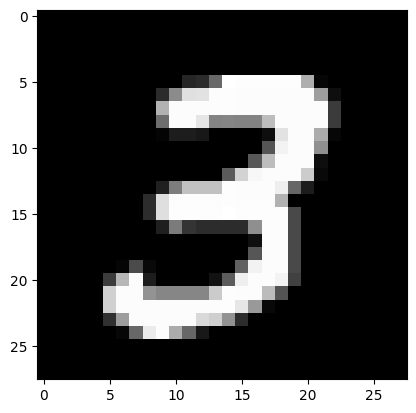

In [49]:
# Example of an image from the dataset
index = 7
plt.imshow(train_set_x_orig[index], cmap='gray')
print ("y = " + str(np.squeeze(train_set_y_orig[index])))

### 1.2 - Convert X and Y into Correct Format

We need to do that because it helps:
- **Easier for compute Loss**
- **Match with Output model**

**_Note:_** We do **NOT need** to **convert classes** because it does **NOT participate** in the **calculation** nor **input** for the **model**.

#### 1.2.1 - Convert X

We convert from: `(batch_size, height, weight)` => `(batch_size, height, weight, channels)`

In [50]:
# ======= Convert X =======
img_height, img_width = train_set_x_orig.shape[1], train_set_x_orig.shape[2]

train_set_x_orig = train_set_x_orig.reshape(-1, img_height, img_width, 1)
test_set_x_orig = test_set_x_orig.reshape(-1, img_height, img_width, 1)
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("test_set_x_orig shape:", test_set_x_orig.shape)

train_set_x_orig shape: (60000, 28, 28, 1)
test_set_x_orig shape: (10000, 28, 28, 1)


#### 1.2.2 - Convert Y

We convert from: 1D `(#label,)` => 2D `(1, #label)`

In [51]:
# ======= Convert Y =======
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
print("train_set_y_orig shape:", train_set_y_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

train_set_y_orig shape: (1, 60000)
test_set_y_orig shape: (1, 10000)


### 1.3 - Convert Classes to One-Hot Representation

We need to know what the representation of classes is to know how we can convert it to One-hot representation.

In [52]:
print("Train: y = " + str(np.squeeze(train_set_y_orig)) + ", Size: " + str(train_set_y_orig.shape))

Train: y = [5 0 4 ... 5 6 8], Size: (1, 60000)


In [53]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

### 1.4 - Split Data

Images are **28x28** pixels in Gray format (1 channels):
- **X_train/X_test shape**: `(batch_size, height, width, channels)`
- **Y_train/Y_test shape**: `(batch_size, #classes_one_hot_represent)`
- **Classes shape**: `(#classes,)`

In [54]:
# Normalize image vectors
X_train = train_set_x_orig/255.
X_test = test_set_x_orig/255.

# Reshape + Convert Y to One-hot
Y_train = convert_to_one_hot(train_set_y_orig, list_classes.shape[0]).T
Y_test = convert_to_one_hot(test_set_y_orig, list_classes.shape[0]).T

# Classes
classes = list_classes

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
print ("Classes shape: " + str(classes.shape))

Number of training examples = 60000
Number of test examples = 10000
X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)
X_test shape: (10000, 28, 28, 1)
Y_test shape: (10000, 10)
Classes shape: (10,)


## 2 - Model Processing

### 2.1 - Create LeNet-5 Model Pipeline

<img src="images/LeNet-5_Pipeline.png">

Use the functions above!

Also, plug in the following parameters for all the steps:

 - [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D): Use 6 5 by 5 filters, stride 1, padding is "VALID"
 - [Sigmoid](https://www.tensorflow.org/api_docs/python/tf/keras/activations/sigmoid)
 - [AvgPool2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/AvgPool2D): Use an 2 by 2 filter size and an 2 by 2 stride, padding is "VALID"
 - **Sigmoid**
 - **Conv2D**: Use 16 5 by 5 filters, stride 1, padding is "VALID"
 - **Sigmoid**
 - **AvgPool2D**: Use an 2 by 2 filter size and an 2 by 2 stride, padding is "VALID"
 - **Sigmoid**
 - [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) the previous output.
 - Fully-connected ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer: Apply a fully connected layer with 120 neurons.
 - **Sigmoid**
 - **Dense**: Apply a fully connected layer with 84 neurons.
 - **Sigmoid**
 - **Dense**: Apply a fully connected layer with 10 neurons.
 - [Softmax](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Softmax): Output probabilities for 10 classes.

**_Note_**: With LeNet-5, we use Input Image (32x32x1). So, we need to **Padding Original Dataset** from **(28x28x1) ⇒ (32x32x1)**

In [55]:
def LeNet5(input_shape):
    """
    Implements the forward propagation for the LeNet-5 model

    Arguments:
    input_img -- input dataset, of shape (input_shape) - (28x28x1)

    Returns:
    model -- TF Keras model (object containing the information for the entire training process)
    """
    input_img = tf.keras.Input(shape=input_shape)
    A0 = tfl.ZeroPadding2D(padding=(2,2))(input_img)

    # 1. Conv
    Z1 = tfl.Conv2D(filters=6, kernel_size=(5, 5), strides=(1, 1), padding='valid')(A0)

    # 2. Sigmoid
    A1 = tfl.Activation('sigmoid')(Z1)

    # 3. AvgPool
    A1_pool = tfl.AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(A1)

    # 4. Sigmoid
    A1_pool_sig = tfl.Activation('sigmoid')(A1_pool)

    # 5. Conv
    Z2 = tfl.Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), padding='valid')(A1_pool_sig)

    # 6. Sigmoid
    A2 = tfl.Activation('sigmoid')(Z2)

    # 7. AvgPool
    A2_pool = tfl.AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(A2)

    # 8. Sigmoid
    A2_pool_sig = tfl.Activation('sigmoid')(A2_pool)

    # 9. Flatten
    F = tfl.Flatten()(A2_pool_sig)

    # 10. Dense 120
    Z3 = tfl.Dense(units=120)(F)

    # 11. Sigmoid
    A3 = tfl.Activation('sigmoid')(Z3)

    # 12. Dense 84
    Z4 = tfl.Dense(units=84)(A3)

    # 13. Sigmoid
    A4 = tfl.Activation('sigmoid')(Z4)

    # 14. Dense 10
    Z5 = tfl.Dense(units=10)(A4)

    # 15. Output: Softmax
    outputs = tfl.Softmax(axis=-1)(Z5)

    model = tf.keras.Model(inputs=input_img, outputs=outputs)
    return model

In [56]:
LeNet5_model = LeNet5((28, 28, 1))
LeNet5_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 32, 32, 1)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 - Set up before Training

Before Training, we need to define:
- How to **Calculate Error**
- How to **Update Weight**
- How to **Measure Performance**

In [57]:
def compile_model(model, optimizer='adam', loss='categorical_crossentropy', metrics='accuracy'):
    model.compile(optimizer=optimizer, loss=loss, metrics=[metrics])
    return model

### 2.3 - Train Model

#### 2.3.1 - Set Path to Save Model After Training

In [58]:
save_dir = "Classical-Model/LeNet-5/models/lenet5_run"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_lenet5.keras")
final_model_path = os.path.join(save_dir, "final_lenet5.keras")

#### 2.3.2 - Load Model If EXIST

In [59]:
# Check if model is loaded!
model_loaded = False

In [60]:
if os.path.exists(best_model_path):
    print("✅ Best Model has been loaded!")
    LeNet5_model = tf.keras.models.load_model(best_model_path)
    model_loaded = True
elif os.path.exists(final_model_path):
    print("✅ Final Model has been loaded!")
    LeNet5_model = tf.keras.models.load_model(final_model_path)
    model_loaded = True
else:
    print("❌ No saved Model! Train a new one!")

✅ Best Model has been loaded!


#### 2.3.3 - Train Model If Necessary

In [61]:
def fit_lenet5(model, X_train, Y_train, X_test, Y_test, best_model_path=best_model_path, final_model_path=final_model_path, batch_size=64, epochs=100):
    # 1. Load Data
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(batch_size)
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size)

    # 2. Checkpoint: Save best model
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True
    )

    # 3. Train Process
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=test_dataset,
        callbacks=[checkpoint]
    )

    # 4. Save final model
    LeNet5_model.save(final_model_path)

    return history

In [62]:
if not model_loaded:
    print("💥 Training Model...")
    LeNet5_model = compile_model(LeNet5_model)
    history = fit_lenet5(LeNet5_model, X_train, Y_train, X_test, Y_test)
else:
    print("✅ Model has been load! No need to train again!")

✅ Model has been load! No need to train again!


## 3 - Test On Real Data

In [63]:
from PIL import Image

✅ Model loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
z7682022129371_e6c14c976beff5fcc792565a88f61da6.jpg: Predicted = 3


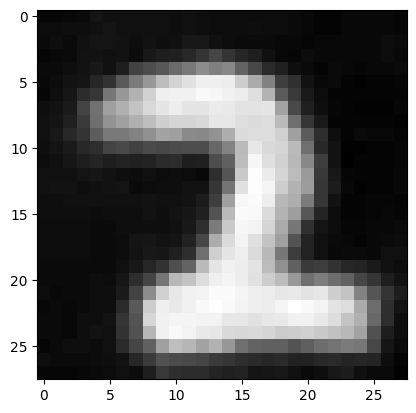

In [81]:
# Folder contains Image
folder_path = r"/mnt/c/Users/PC/Desktop/test_image"

# Load model
model_path = best_model_path  # or "final_model_path"
LeNet5_model = tf.keras.models.load_model(model_path)
print("✅ Model loaded.")

# Retrieve for each image
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        img_path = os.path.join(folder_path, filename)

        # 1️. Open image, resize into 28x28, convert grayscale
        img = Image.open(img_path).resize((28,28)).convert('L')

        # 2️. Convert into numpy array, scale 0-1
        img_array = 1 - np.array(img).astype('float32') / 255.0
        plt.imshow(img_array, cmap='gray')

        # 3️. Add "channels" and "batch_size" dimension
        img_array = np.expand_dims(img_array, axis=-1)  # (28,28,1)
        img_array = np.expand_dims(img_array, axis=0)   # (1,28,28,1)

        # 4️. Predict
        pred = LeNet5_model.predict(img_array)
        pred_class = np.argmax(pred, axis=1)[0]

        print(f"{filename}: Predicted = {pred_class}")